# Synthetic Graph EDA

In [35]:
import os
from dgl import save_graphs, load_graphs
from dgl.data.utils import makedirs, save_info, load_info
import networkx as nx

In [36]:
# Config
ORG_DATASET = "reddit"
TASK = "hidden_labels"      # 'hidden_labels' or 'hidden_links'
SUBDIR = "normalized_lw_scaling_3"  # subdirectory within the task folder to compare

# Feature comparison mode:
#   True  -> normalise the original features (compare in normalised space)
#   False -> unnormalise the synthetic features (compare in original space)
SHOW_NORMALIZED = True

## Original Graph

In [37]:
PATH = f'../datasets/original/{ORG_DATASET}'
original_graph, _ = load_graphs(PATH)
 
original_graph = original_graph[0]

In [38]:
org_graph_num_nodes = original_graph.num_nodes()
org_graph_num_edges = original_graph.num_edges()
org_graph_num_anomalies = original_graph.ndata['label'].tolist().count(1)

org_graph_ndata_keys = list(original_graph.ndata.keys())
org_graph_train_masks_shape = original_graph.ndata['train_masks'].shape

## Synthetic Graphs

In [39]:
syn_base_path = f'../datasets/synthetic/bigg/{ORG_DATASET}/{TASK}/{SUBDIR}'
syn_names = sorted(os.listdir(syn_base_path))

print(f"Found {len(syn_names)} datasets in '{SUBDIR}':")
for name in syn_names:
    print(f"  {name}")

synthetic_graphs = {}
for name in syn_names:
    graphs, _ = load_graphs(f'{syn_base_path}/{name}')
    synthetic_graphs[name] = graphs[0]

Found 3 datasets in 'normalized_lw_scaling_3':
  blksize_-1_b_1_lr_0.001_epochs_300_noise_0.1_ss_0.0_norm_zscore_bfs_lw_0.01_0.01
  blksize_-1_b_1_lr_0.001_epochs_300_noise_0.1_ss_0.0_norm_zscore_bfs_lw_0.1_0.1
  blksize_-1_b_1_lr_0.001_epochs_300_noise_0.1_ss_0.0_norm_zscore_bfs_lw_1_1


## Summary

In [40]:
import pandas as pd
import torch

def split_summary(graph, mask_key):
    if mask_key not in graph.ndata:
        return "N/A"
    counts = graph.ndata[mask_key].float().sum(0)
    return f"{counts.mean():.0f} (min {counts.min():.0f}, max {counts.max():.0f})"

def graph_summary(graph):
    zero_indegree = int((graph.in_degrees() == 0).sum())
    return {
        "Nodes": graph.num_nodes(),
        "Edges": graph.num_edges(),
        "Anomalies": graph.ndata['label'].tolist().count(1),
        "Nodes with 0 in-degree": f"⚠️{zero_indegree}" if zero_indegree > 0 else "N/A",
        "ndata keys": str(list(graph.ndata.keys())),
        "train_masks shape": str(tuple(graph.ndata['train_masks'].shape)) if 'train_masks' in graph.ndata else "N/A",
        "Train nodes/split": split_summary(graph, "train_masks"),
        "Val nodes/split": split_summary(graph, "val_masks"),
        "Test nodes/split": split_summary(graph, "test_masks"),
    }

rows = {"Original": graph_summary(original_graph)}
for name, g in synthetic_graphs.items():
    rows[name] = graph_summary(g)

display(pd.DataFrame(rows))

,Original,blksize_-1_b_1_lr_0.001_epochs_300_noise_0.1_ss_0.0_norm_zscore_bfs_lw_0.01_0.01,blksize_-1_b_1_lr_0.001_epochs_300_noise_0.1_ss_0.0_norm_zscore_bfs_lw_0.1_0.1,blksize_-1_b_1_lr_0.001_epochs_300_noise_0.1_ss_0.0_norm_zscore_bfs_lw_1_1
Nodes,10984,10984,10984,10984
Edges,168016,134664,224026,179090
Anomalies,366,318,466,299
Nodes with 0 in-degree,N/A,N/A,N/A,⚠️33
ndata keys,"['feature', 'label', 'train_masks', 'val_masks...","['test_masks', 'val_masks', 'train_masks', 'la...","['test_masks', 'val_masks', 'train_masks', 'la...","['test_masks', 'val_masks', 'train_masks', 'la..."
train_masks shape,"(10984, 20)","(10984, 20)","(10984, 20)","(10984, 20)"
Train nodes/split,"2246 (min 100, max 4393)","2246 (min 100, max 4393)","2246 (min 100, max 4393)","2246 (min 100, max 4393)"
Val nodes/split,"1148 (min 100, max 2196)","1148 (min 100, max 2196)","1148 (min 100, max 2196)","1148 (min 100, max 2196)"
Test nodes/split,"7590 (min 4395, max 10784)","0 (min 0, max 0)","0 (min 0, max 0)","0 (min 0, max 0)"


## Graph Statistics

**Convert dgl graph to NetworkX**

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import torch

org_nx = nx.Graph(original_graph.to_networkx())
syn_nx_graphs = {name: nx.Graph(g.to_networkx()) for name, g in synthetic_graphs.items()}

### Degree Distribution

,Original,blksize_-1_b_1_lr_0.001_epochs_300_noise_0.1_ss_0.0_norm_zscore_bfs_lw_0.01_0.01,blksize_-1_b_1_lr_0.001_epochs_300_noise_0.1_ss_0.0_norm_zscore_bfs_lw_0.1_0.1,blksize_-1_b_1_lr_0.001_epochs_300_noise_0.1_ss_0.0_norm_zscore_bfs_lw_1_1
Mean,16.30,12.26,20.40,16.30
Median,8.0,6.0,9.0,12.0
Max,2557,1029,2083,5429


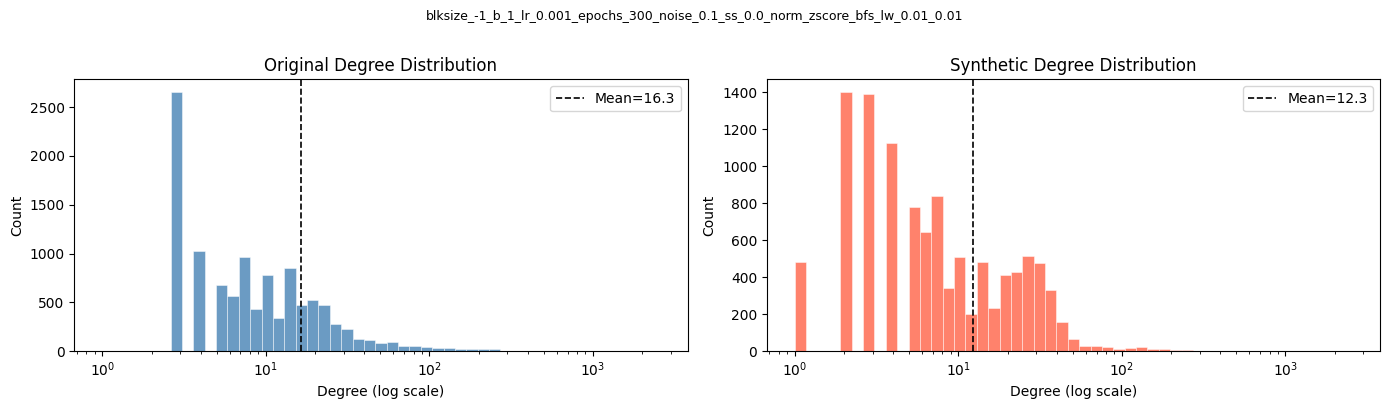

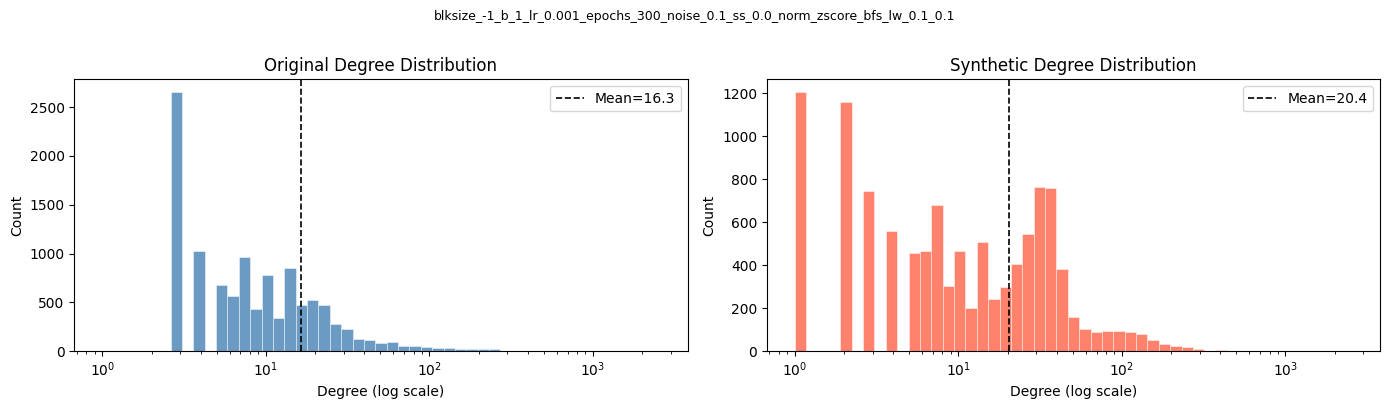

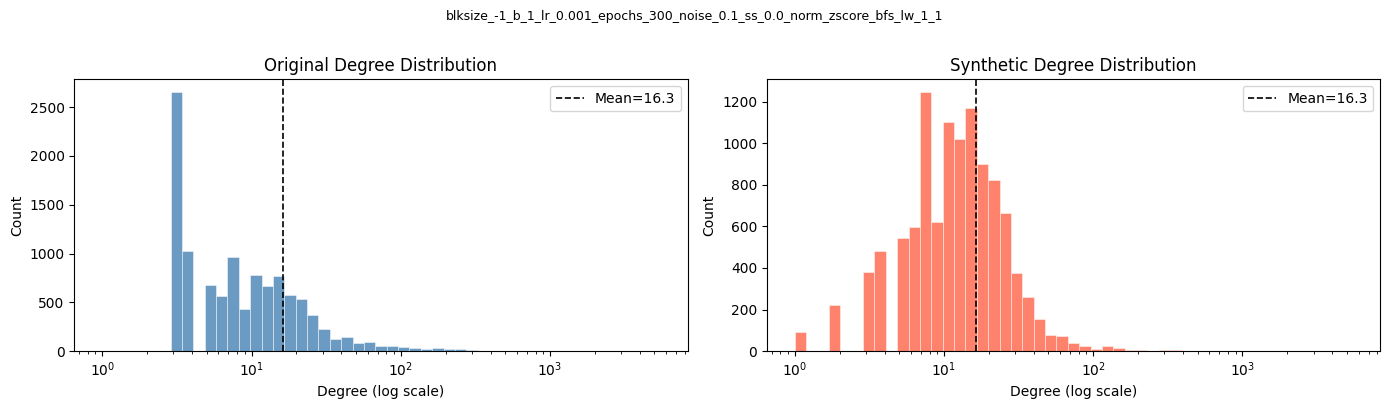

In [42]:
org_degrees = [d for _, d in org_nx.degree()]

degree_stats = {"Original": {
    "Mean": f"{np.mean(org_degrees):.2f}",
    "Median": f"{np.median(org_degrees):.1f}",
    "Max": max(org_degrees),
}}
for name, g_nx in syn_nx_graphs.items():
    degs = [d for _, d in g_nx.degree()]
    degree_stats[name] = {
        "Mean": f"{np.mean(degs):.2f}",
        "Median": f"{np.median(degs):.1f}",
        "Max": max(degs),
    }

display(pd.DataFrame(degree_stats))

# One plot per synthetic dataset
for name, g_nx in syn_nx_graphs.items():
    syn_degrees = [d for _, d in g_nx.degree()]
    max_degree = max(max(org_degrees), max(syn_degrees))
    bins = np.logspace(0, np.log10(max_degree + 1), 50)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
    for ax, degrees, label, color in zip(
        axes,
        [org_degrees, syn_degrees],
        ["Original", "Synthetic"],
        ["steelblue", "tomato"],
    ):
        ax.hist(degrees, bins=bins, color=color, alpha=0.8, edgecolor="white", linewidth=0.4)
        ax.set_xscale("log")
        ax.set_xlabel("Degree (log scale)")
        ax.set_ylabel("Count")
        ax.set_title(f"{label} Degree Distribution")
        ax.axvline(np.mean(degrees), color="black", linestyle="--", linewidth=1.2, label=f"Mean={np.mean(degrees):.1f}")
        ax.legend()

    plt.suptitle(name, fontsize=9, y=1.01)
    plt.tight_layout()
    plt.show()

### Clustering Coefficient

,Original,blksize_-1_b_1_lr_0.001_epochs_300_noise_0.1_ss_0.0_norm_zscore_bfs_lw_0.01_0.01,blksize_-1_b_1_lr_0.001_epochs_300_noise_0.1_ss_0.0_norm_zscore_bfs_lw_0.1_0.1,blksize_-1_b_1_lr_0.001_epochs_300_noise_0.1_ss_0.0_norm_zscore_bfs_lw_1_1
Avg clustering coeff,0.0000,0.0010,0.0052,0.0695


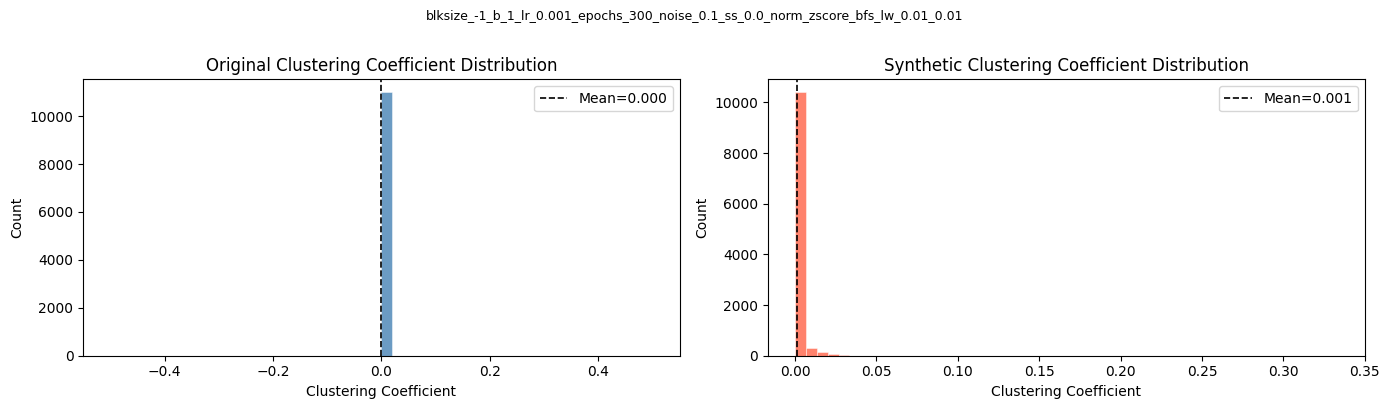

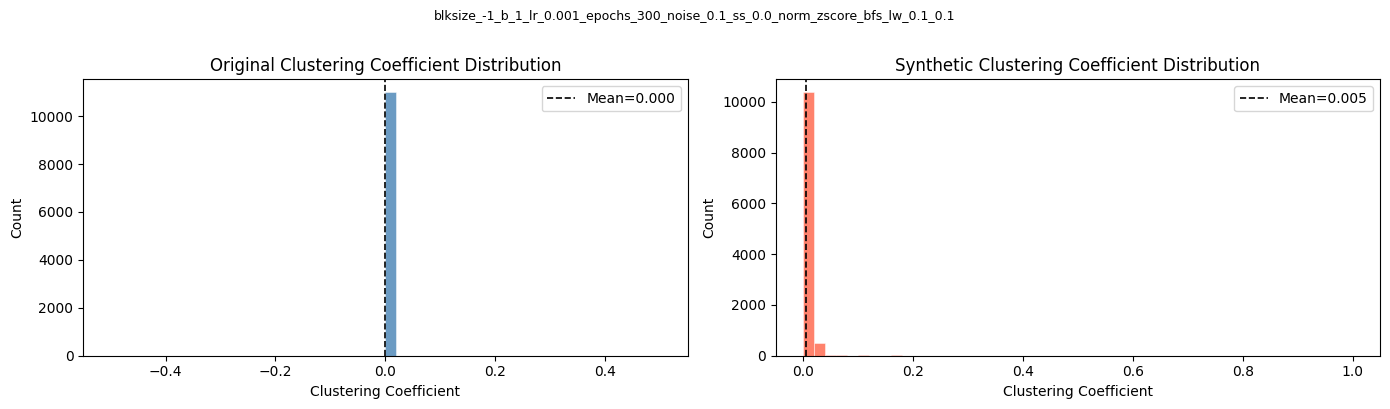

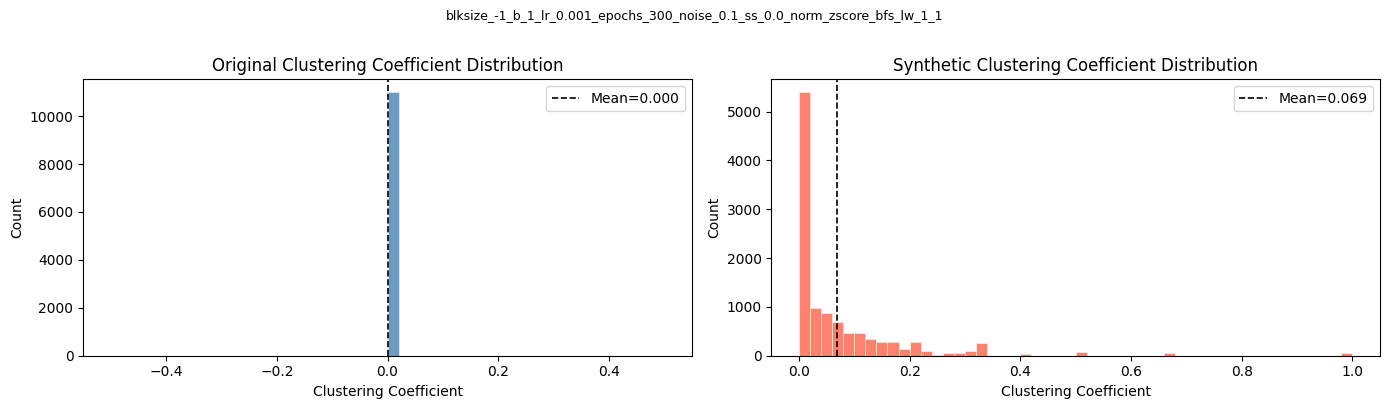

In [43]:
cc_stats = {"Original": {"Avg clustering coeff": f"{nx.average_clustering(org_nx):.4f}"}}
for name, g_nx in syn_nx_graphs.items():
    cc_stats[name] = {"Avg clustering coeff": f"{nx.average_clustering(g_nx):.4f}"}

display(pd.DataFrame(cc_stats))

# One plot per synthetic dataset
org_cc = list(nx.clustering(org_nx).values())
for name, g_nx in syn_nx_graphs.items():
    syn_cc = list(nx.clustering(g_nx).values())

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, cc_vals, label, color in zip(
        axes,
        [org_cc, syn_cc],
        ["Original", "Synthetic"],
        ["steelblue", "tomato"],
    ):
        ax.hist(cc_vals, bins=50, color=color, alpha=0.8, edgecolor="white", linewidth=0.4)
        ax.set_xlabel("Clustering Coefficient")
        ax.set_ylabel("Count")
        ax.set_title(f"{label} Clustering Coefficient Distribution")
        ax.axvline(np.mean(cc_vals), color="black", linestyle="--", linewidth=1.2, label=f"Mean={np.mean(cc_vals):.3f}")
        ax.legend()

    plt.suptitle(name, fontsize=9, y=1.01)
    plt.tight_layout()
    plt.show()

### Feature Distribution

In [44]:
org_feats = original_graph.ndata['feature'].numpy()   # shape [N, feat_dim]
feat_dim = org_feats.shape[1]
print(f"Feature dimensionality: {feat_dim}")

# Compute zscore stats from original
org_mean = org_feats.mean(axis=0)
org_std = org_feats.std(axis=0)
org_std[org_std == 0] = 1.0

if SHOW_NORMALIZED:
    org_feats_cmp = (org_feats - org_mean) / org_std
    mode_label = "normalised"
else:
    org_feats_cmp = org_feats.copy()
    mode_label = "original"

print(f"Comparing in {mode_label} space\n")

# Build per-dataset comparison in normalised/original space
syn_feats_all = {}
for name, g in synthetic_graphs.items():
    sf = g.ndata['feature'].numpy()
    syn_feats_all[name] = sf if SHOW_NORMALIZED else sf * org_std + org_mean

# Summary: mean absolute bias and avg std ratio per dataset
feat_summary = {}
for name, sf in syn_feats_all.items():
    mean_bias = np.abs(sf.mean(axis=0) - org_feats_cmp.mean(axis=0)).mean()
    std_ratio = (sf.std(axis=0) / np.maximum(org_feats_cmp.std(axis=0), 1e-8)).mean()
    feat_summary[name] = {
        "Mean |bias| (avg over feats)": f"{mean_bias:.4f}",
        "Avg std ratio (syn/org)": f"{std_ratio:.4f}",
    }
display(pd.DataFrame(feat_summary))

# Per-feature table
print(f"\nPer-feature mean / std:")
header = f"{'Feat':>5} | {'Org μ':>9} {'Org σ':>7}"
for name in syn_feats_all:
    short = name[:14]
    header += f" | {short+' μ':>16} {short+' σ':>14}"
print(header)
print("-" * len(header))
for i in range(feat_dim):
    row = f"{i:>5} | {org_feats_cmp[:, i].mean():>9.4f} {org_feats_cmp[:, i].std():>7.4f}"
    for sf in syn_feats_all.values():
        row += f" | {sf[:, i].mean():>16.4f} {sf[:, i].std():>14.4f}"
    print(row)

Feature dimensionality: 64
Comparing in normalised space



,blksize_-1_b_1_lr_0.001_epochs_300_noise_0.1_ss_0.0_norm_zscore_bfs_lw_0.01_0.01,blksize_-1_b_1_lr_0.001_epochs_300_noise_0.1_ss_0.0_norm_zscore_bfs_lw_0.1_0.1,blksize_-1_b_1_lr_0.001_epochs_300_noise_0.1_ss_0.0_norm_zscore_bfs_lw_1_1
Mean |bias| (avg over feats),0.0964,0.0739,0.0671
Avg std ratio (syn/org),0.2856,0.3486,0.2008



Per-feature mean / std:
 Feat |     Org μ   Org σ | blksize_-1_b_1 μ blksize_-1_b_1 σ | blksize_-1_b_1 μ blksize_-1_b_1 σ | blksize_-1_b_1 μ blksize_-1_b_1 σ
-------------------------------------------------------------------------------------------------------------------------------------
    0 |    0.0000  1.0000 |           0.0929         0.1857 |          -0.0666         0.2844 |           0.0781         0.1690
    1 |    0.0000  1.0000 |           0.1437         0.2237 |          -0.1300         0.2700 |          -0.0056         0.1649
    2 |   -0.0000  1.0000 |           0.0713         0.1805 |          -0.0076         0.2869 |          -0.0013         0.1536
    3 |   -0.0000  1.0000 |           0.0345         0.1999 |           0.0064         0.2728 |          -0.0672         0.1573
    4 |    0.0000  1.0000 |          -0.0770         0.1947 |          -0.0259         0.2996 |          -0.1292         0.1756
    5 |    0.0000  1.0000 |          -0.1484         0.2550 |      

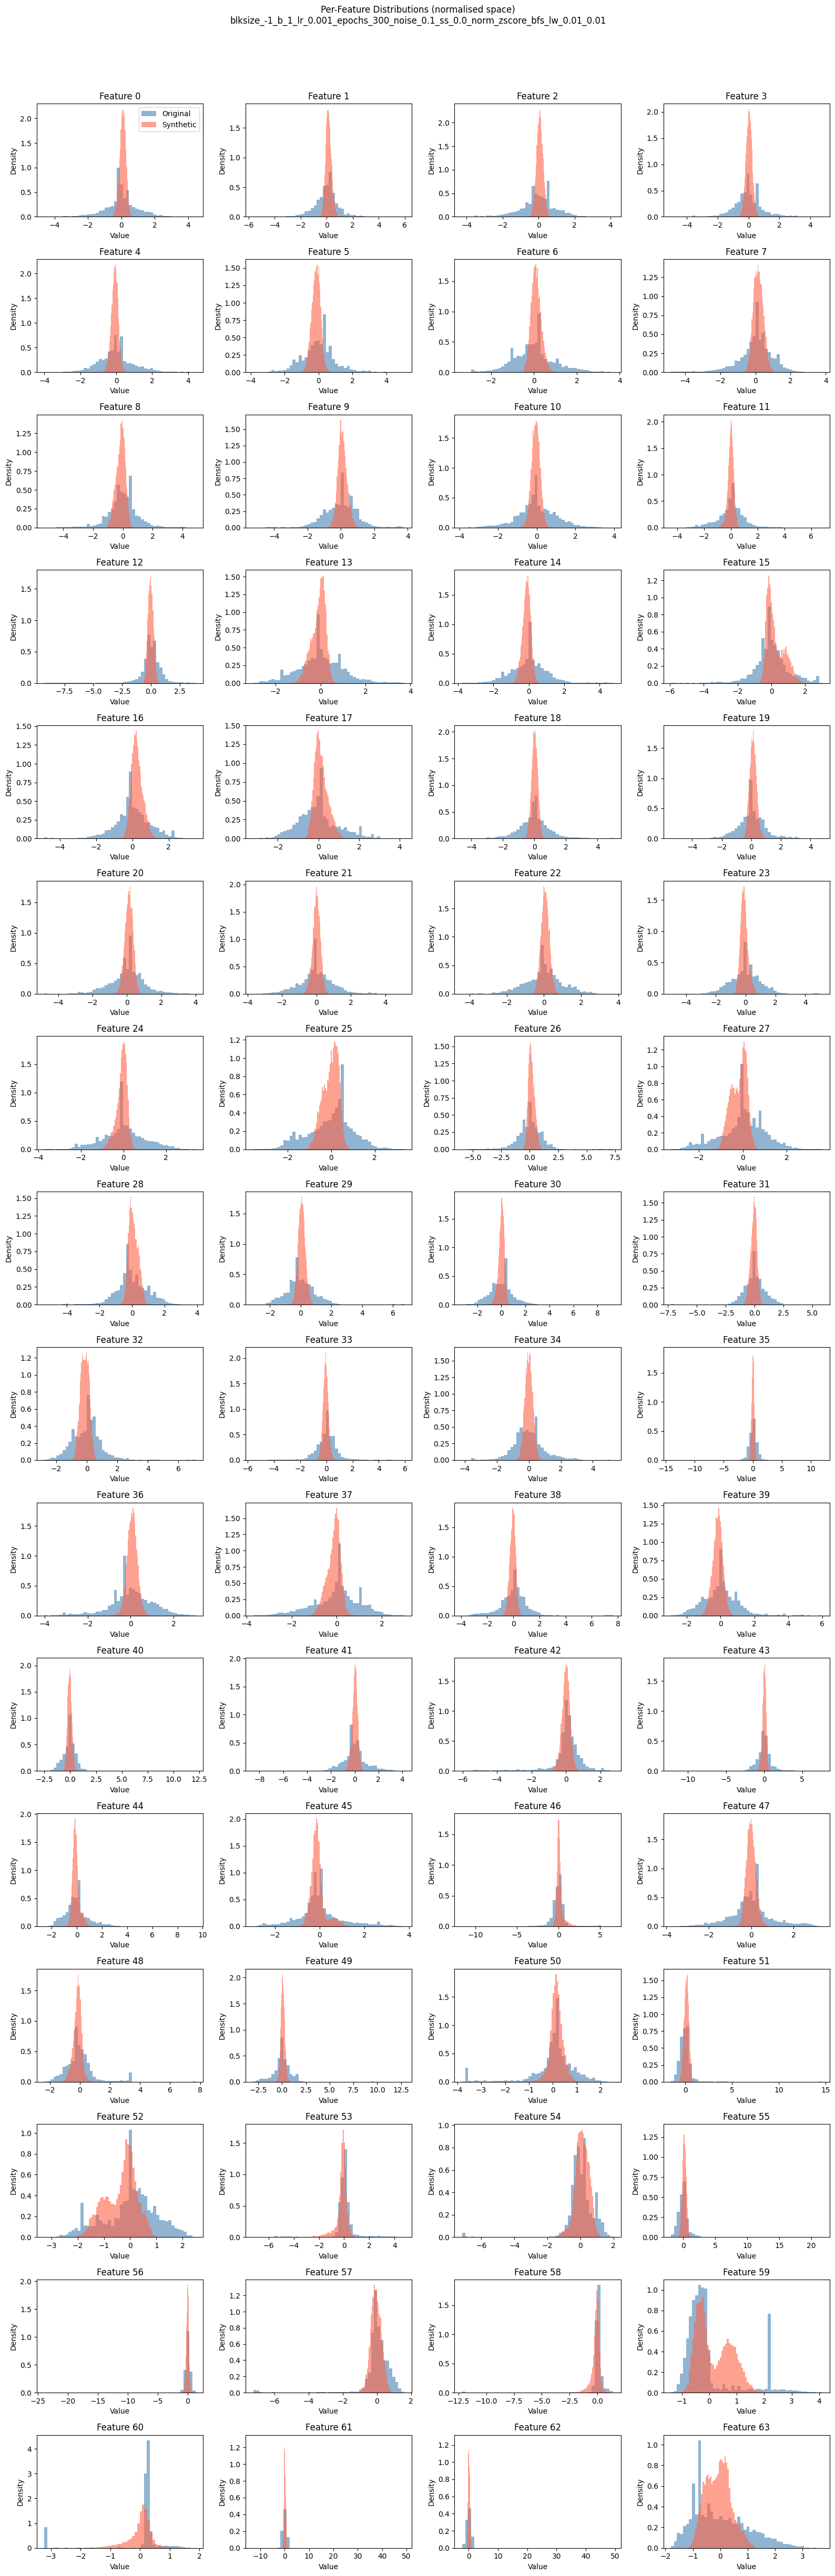

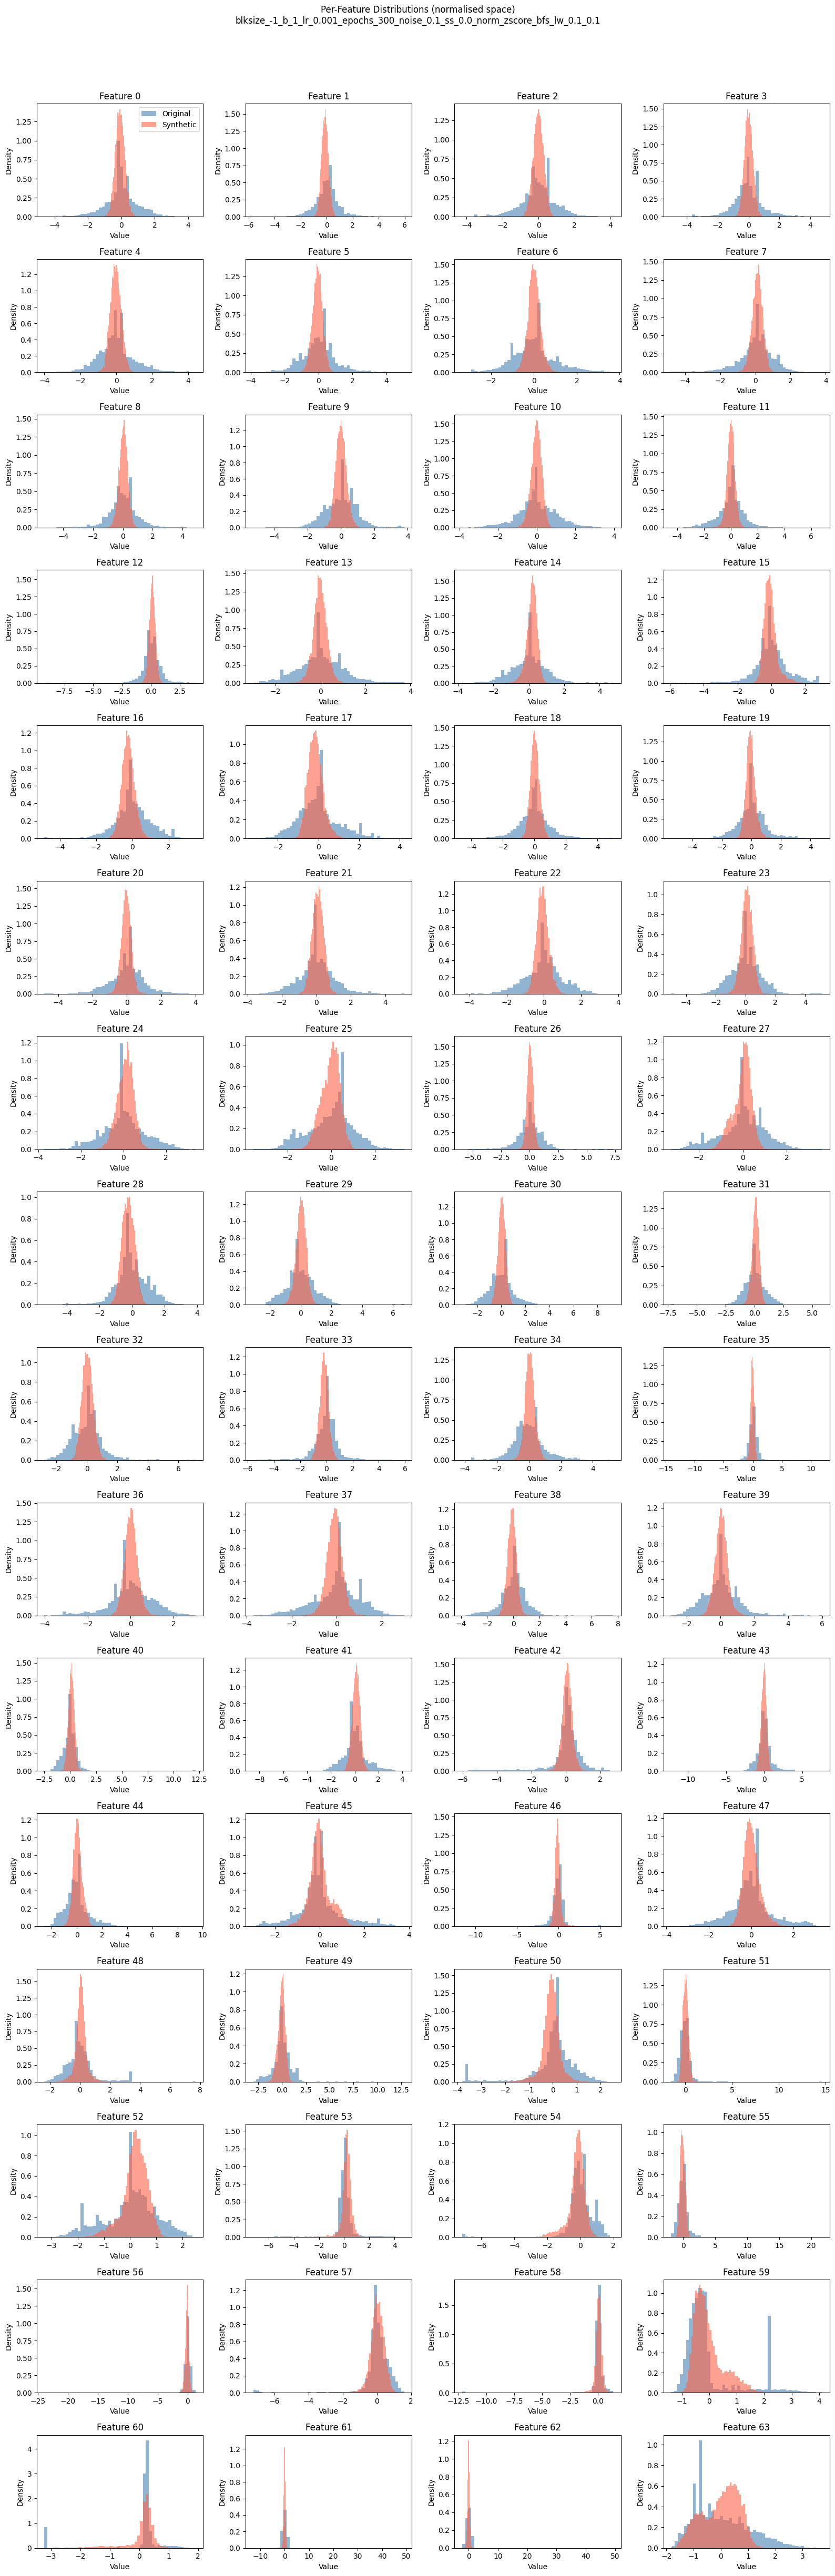

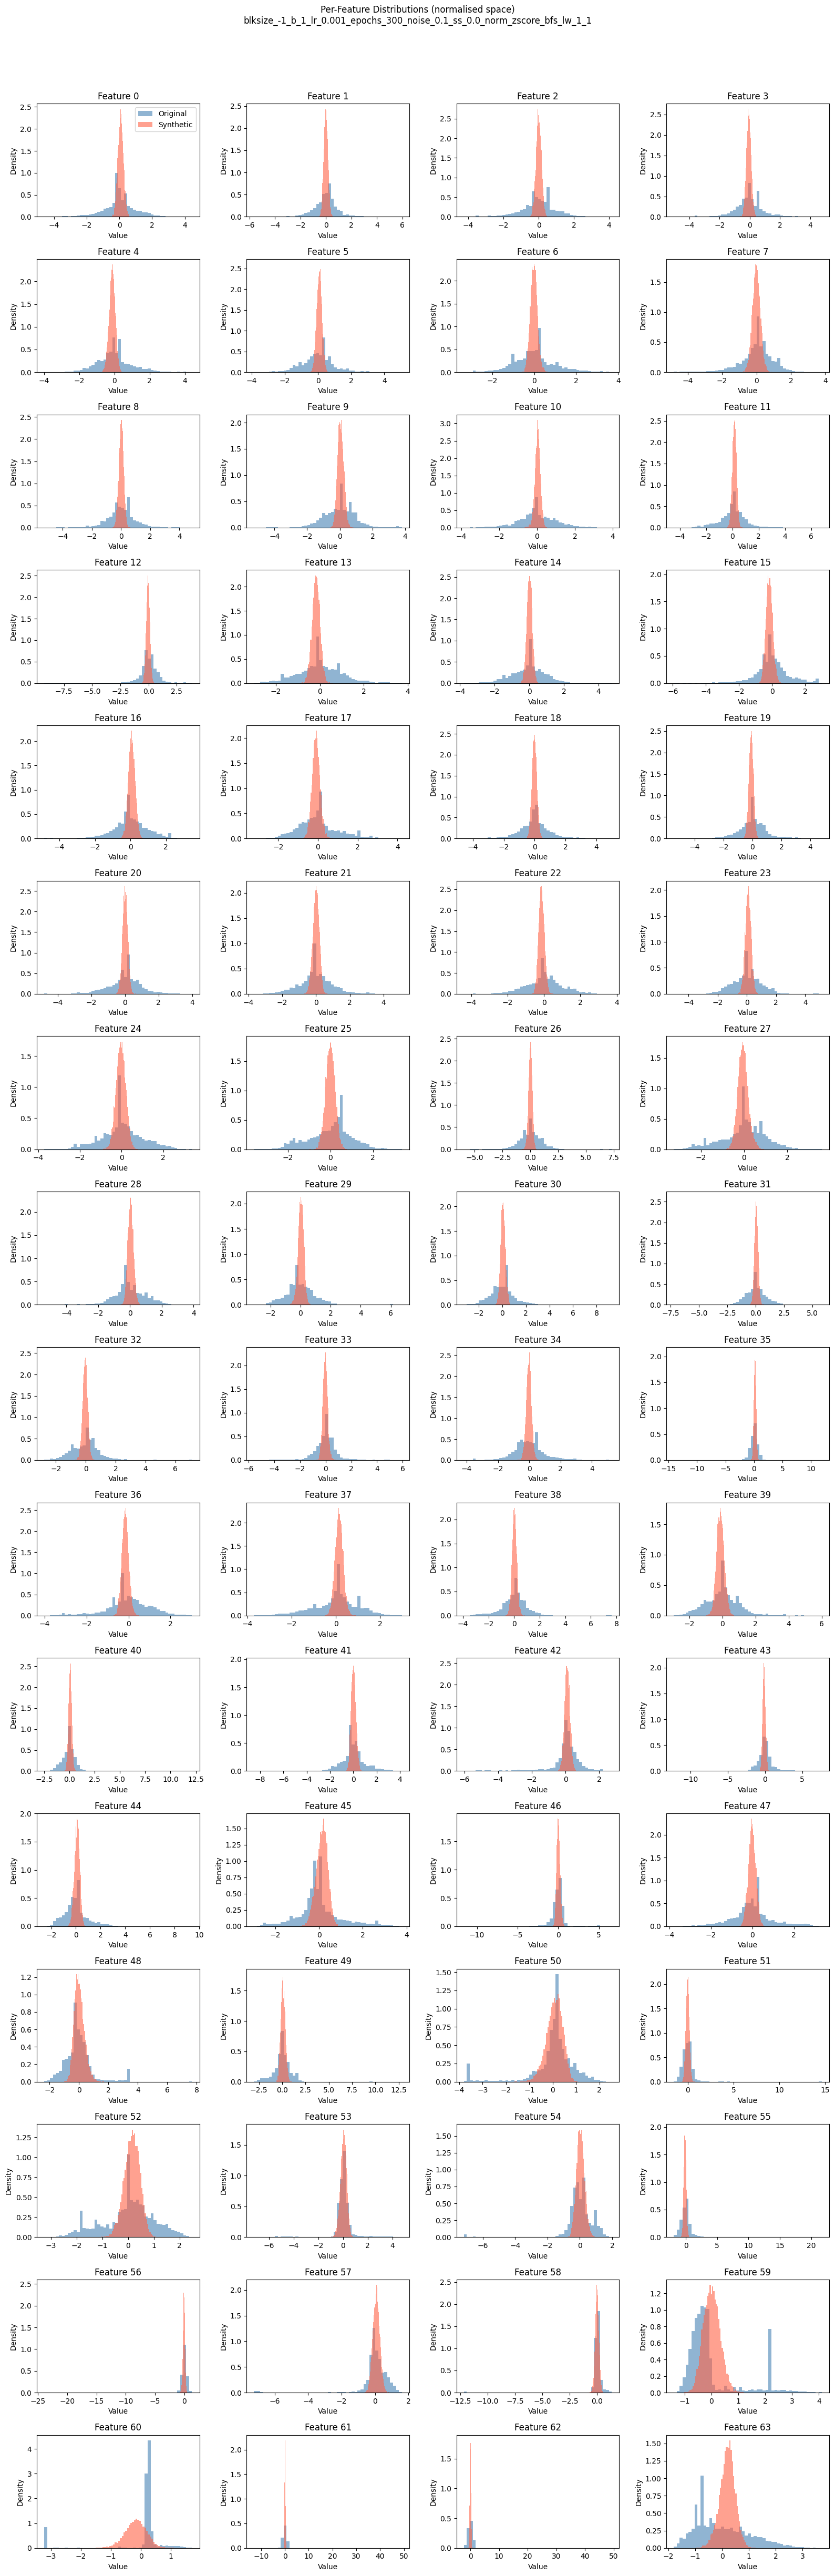

In [45]:
# Per-feature distribution plots — one figure per synthetic dataset
ncols = 4
nrows = (feat_dim + ncols - 1) // ncols

for name, syn_feats_cmp in syn_feats_all.items():
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
    axes = axes.flatten()

    for i in range(feat_dim):
        ax = axes[i]
        ax.hist(org_feats_cmp[:, i], bins=50, alpha=0.6, label="Original", color="steelblue", density=True)
        ax.hist(syn_feats_cmp[:, i], bins=50, alpha=0.6, label="Synthetic", color="tomato", density=True)
        ax.set_title(f"Feature {i}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Density")
        if i == 0:
            ax.legend()

    for j in range(feat_dim, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f"Per-Feature Distributions ({mode_label} space)\n{name}", y=1.02)
    plt.tight_layout()
    plt.show()

## Add Train/Val/Test Masks

In [14]:
# import torch

# num_nodes = synthetic_graph.num_nodes()
# num_splits = graph.ndata['train_masks'].shape[1]  # 20

# synthetic_graph.ndata['train_masks'] = torch.ones(num_nodes, num_splits, dtype=torch.uint8)
# synthetic_graph.ndata['val_masks'] = torch.zeros(num_nodes, num_splits, dtype=torch.uint8)
# synthetic_graph.ndata['test_masks'] = torch.zeros(num_nodes, num_splits, dtype=torch.uint8)

# save_graphs(synthetic_path, [synthetic_graph])
# print("Saved with masks:", list(synthetic_graph.ndata.keys()))